In [1]:
!pip install -q datasets transformers jiwer librosa soundfile accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.2 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import pandas as pd
import librosa
import unicodedata
import re
import json
import os
import time
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset, Audio
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from jiwer import wer, cer
from IPython.display import Audio as IPAudio, display
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# əlavə gpu testi
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'GPU sayı: {torch.cuda.device_count()}')

MODEL_ID        = 'openai/whisper-large-v3'
LANGUAGE        = 'azerbaijani'
TASK            = 'transcribe'
SAMPLE_RATE     = 16000
NUM_TEST        = 200
BATCH_SIZE      = 8

os.makedirs('results', exist_ok=True)

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
GPU sayı: 2


In [3]:
print(NUM_TEST)

200


# https://commonvoice.mozilla.org/az/datasets

In [4]:
%%bash
RESPONSE=$(curl -X POST "https://mozilladatacollective.com/api/datasets/cmn29hqvk015ko107fblsr5ay/download" \
  -H "Authorization: Bearer API_KEY" \
  -H "Content-Type: application/json")

DOWNLOAD_URL=$(echo $RESPONSE | jq -r '.downloadUrl')

curl -o "cv_az.tar.gz" "$DOWNLOAD_URL"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   890    0   890    0     0   1435      0 --:--:-- --:--:-- --:--:--  1435
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 36.6M  100 36.6M    0     0  23.2M      0  0:00:01  0:00:01 --:--:-- 23.2M


In [5]:
!mkdir -p ./cv_data

In [6]:
!tar -xf cv_az.tar.gz -C ./cv_data

In [7]:
!ls -R ./cv_data

./cv_data:
cv-corpus-25.0-2026-03-09

./cv_data/cv-corpus-25.0-2026-03-09:
az

./cv_data/cv-corpus-25.0-2026-03-09/az:
clip_durations.tsv  invalidated.tsv  reported.tsv  unvalidated_sentences.tsv
clips		    other.tsv	     test.tsv	   validated_sentences.tsv
dev.tsv		    README.md	     train.tsv	   validated.tsv

./cv_data/cv-corpus-25.0-2026-03-09/az/clips:
common_voice_az_26658644.mp3  common_voice_az_40699344.mp3
common_voice_az_26658645.mp3  common_voice_az_40699345.mp3
common_voice_az_26658646.mp3  common_voice_az_40699346.mp3
common_voice_az_26658647.mp3  common_voice_az_40699347.mp3
common_voice_az_26658771.mp3  common_voice_az_40699348.mp3
common_voice_az_26658772.mp3  common_voice_az_40699349.mp3
common_voice_az_26658773.mp3  common_voice_az_40699350.mp3
common_voice_az_26658774.mp3  common_voice_az_40699351.mp3
common_voice_az_26658775.mp3  common_voice_az_40699352.mp3
common_voice_az_26658842.mp3  common_voice_az_40699353.mp3
common_voice_az_26658844.mp3  common_voice_az_4069

# DATASET

In [8]:
from datasets import Dataset, Audio

base_folder = "./cv_data/cv-corpus-25.0-2026-03-09/az/" 
df = pd.read_csv(f"{base_folder}test.tsv", sep='\t')
df = df.head(126)
df['audio'] = base_folder + "clips/" + df['path']

dataset = Dataset.from_pandas(df)
dataset = dataset.cast_column("audio", Audio(sampling_rate=SAMPLE_RATE))
print(f"Samples: {len(dataset)}")

Samples: 126


# MODELIN QURULMASI

In [9]:
processor = WhisperProcessor.from_pretrained(MODEL_ID)
model = WhisperForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
).to(device)

model.eval()
print('yuklendi')

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

yuklendi


# NORMALIZATION

In [10]:
def normalize_text(text: str) -> str:
    if not text:
        return ""
    text = unicodedata.normalize('NFKC', text)
    az_upper = "İIƏĞÜŞÇ"
    az_lower = "iıəğüşç"
    translation_table = str.maketrans(az_upper, az_lower)
    text = text.translate(translation_table)
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', ' ', text, flags=re.UNICODE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [11]:
print(df.columns.tolist())

['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment', 'audio']


# Transcribe 

In [12]:
def transcribe_batch(batch):
    audio_arrays = [s['array'] for s in batch['audio']]

    inputs = processor(
        audio_arrays,
        sampling_rate=SAMPLE_RATE,
        return_tensors='pt',
        padding=True
    )
    input_features = inputs.input_features.to(device, dtype=torch.float16)

    with torch.no_grad():
        predicted_ids = model.generate(
            input_features,
            language=LANGUAGE,
            task=TASK,
            max_new_tokens=225,
            no_repeat_ngram_size=3
        )

    transcriptions = processor.batch_decode(predicted_ids, skip_special_tokens=True)
    batch['prediction'] = transcriptions
    return batch

# Inference 

In [13]:
print(f'{len(dataset)} Sample:')
start = time.time()

result_ds = dataset.map(
    transcribe_batch,
    batched=True,
    batch_size=BATCH_SIZE,
    desc='Transcribing'
)

elapsed = time.time() - start
print(f'{elapsed:.1f}s  ({elapsed/len(dataset):.1f}s/sample)')

126 Sample:


Transcribing:   0%|          | 0/126 [00:00<?, ? examples/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'trans

58.9s  (0.5s/sample)


# WER/CER

In [14]:
references  = [normalize_text(str(s)) for s in result_ds['sentence']]
predictions = [normalize_text(s) for s in result_ds['prediction']]

wer = [wer(r, p) for r, p in zip(references, predictions)]
cer = [cer(r, p) for r, p in zip(references, predictions)]
avg_wer = np.mean(wer)
avg_cer = np.mean(cer)



In [15]:
print(f'  Ortalama WER : {avg_wer*100:.2f}%')
print(f'  Ortalama CER : {avg_cer*100:.2f}%')
print(f'  Nümunə sayı  : {len(references)}')

  Ortalama WER : 27.12%
  Ortalama CER : 7.21%
  Nümunə sayı  : 126


# SUMMARIZE

In [16]:
df_results = pd.DataFrame({
    'reference':  references,
    'prediction': predictions,
    'WER':        [round(w*100, 2) for w in wer],
    'CER':        [round(c*100, 2) for c in cer]
})

df_sorted = df_results.sort_values('WER').reset_index(drop=True)
print('Top 5:')
for _, row in df_sorted.head(5).iterrows():
    print(f"  REF : {row['reference']}")
    print(f"  PRED: {row['prediction']}")
    print(f"  WER={row['WER']}%  CER={row['CER']}%\n")

print('Worst 5:')
for _, row in df_sorted.tail(5).iterrows():
    print(f"  REF : {row['reference']}")
    print(f"  PRED: {row['prediction']}")
    print(f"  WER={row['WER']}%  CER={row['CER']}%\n")

Top 5:
  REF : həmin il yaponiya misirin müstəqilliyini tanımışdır
  PRED: həmin il yaponiya misirin müstəqilliyini tanımışdır
  WER=0.0%  CER=0.0%

  REF : bunun səbəbləri müxtəlifdir
  PRED: bunun səbəbləri müxtəlifdir
  WER=0.0%  CER=0.0%

  REF : qrup artıq fəaliyyətini dayandırmışdır
  PRED: qrup artıq fəaliyyətini dayandırmışdır
  WER=0.0%  CER=0.0%

  REF : adada göl yoxdur
  PRED: adada göl yoxdur
  WER=0.0%  CER=0.0%

  REF : təhsilini davam etdirmək istəsə də mümkün olmayıb
  PRED: təhsilini davam etdirmək istəsə də mümkün olmayıb
  WER=0.0%  CER=0.0%

Worst 5:
  REF : göl balıqçılıq üçün əlverişlidir
  PRED: göv balıqçılığı üçün əlbərişlidir
  WER=75.0%  CER=15.62%

  REF : bütün işlər barışıq hakimi tərəfindən təkbaşına həll edilirdi
  PRED: bütün müşlər qarışıq hakimi tərəfindən tək başına hələ dilirdi
  WER=75.0%  CER=9.84%

  REF : həmin dövrdən indiyədək heydər əliyev adına saraya ləyaqətlə rəhbərlik edir
  PRED: həmin dövrdən indiyana dək heydar ali vadnaz saraya ləyəq

# LISTENING CHECK

In [17]:
print('WORST 5:')
worst_indices = df_results.nlargest(5, 'WER').index.tolist()

for rank, idx in enumerate(worst_indices, 1):
    row = df_results.iloc[idx]
    print(f'\n#{rank} — WER: {row["WER"]}%')
    print(f'  REF : {row["reference"]}')
    print(f'  PRED: {row["prediction"]}')
    display(IPAudio(result_ds[int(idx)]['audio']['array'], rate=SAMPLE_RATE))

WORST 5:

#1 — WER: 100.0%
  REF : netflix nədir
  PRED: netflixs nədər



#2 — WER: 100.0%
  REF : bir oğul övladı var
  PRED: piroqlu vladovar



#3 — WER: 80.0%
  REF : həmin dövrdən indiyədək heydər əliyev adına saraya ləyaqətlə rəhbərlik edir
  PRED: həmin dövrdən indiyana dək heydar ali vadnaz saraya ləyəqətlə rəhbərliyidir



#4 — WER: 75.0%
  REF : göl balıqçılıq üçün əlverişlidir
  PRED: göv balıqçılığı üçün əlbərişlidir



#5 — WER: 75.0%
  REF : bütün işlər barışıq hakimi tərəfindən təkbaşına həll edilirdi
  PRED: bütün müşlər qarışıq hakimi tərəfindən tək başına hələ dilirdi


# PLOTTING

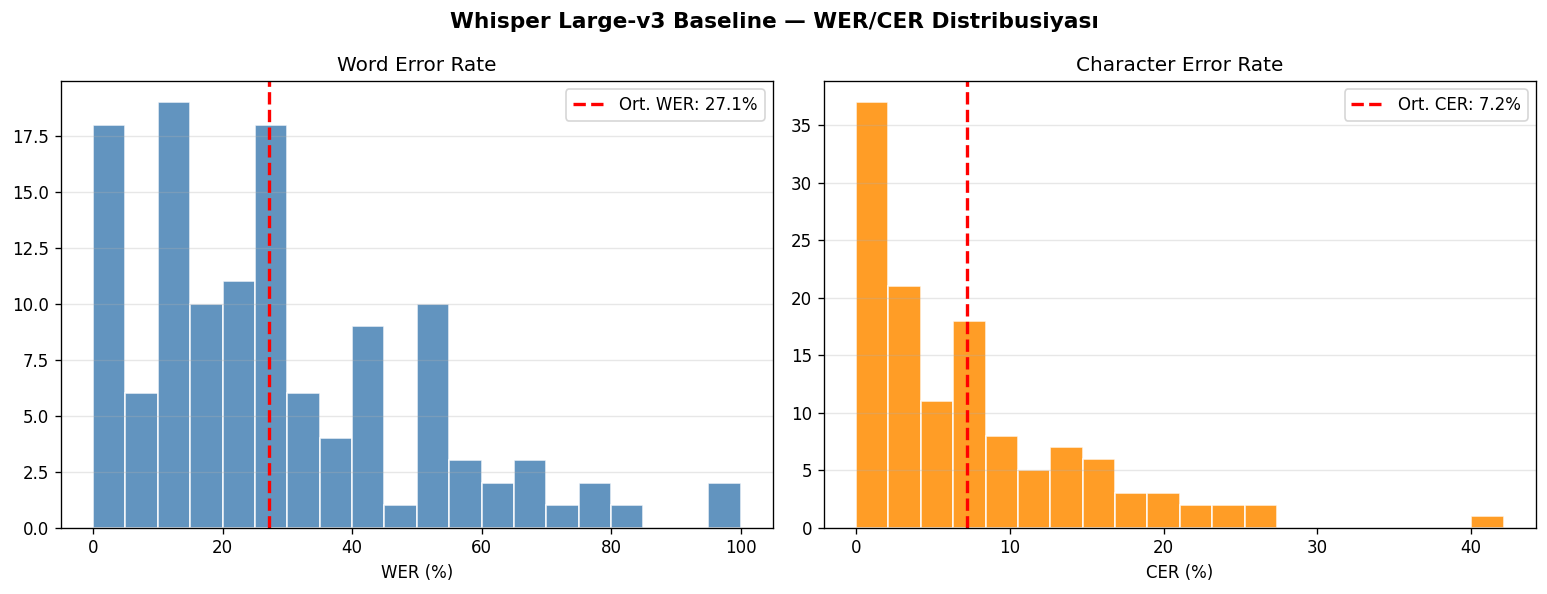

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Whisper Large-v3 Baseline — WER/CER Distribusiyası', fontsize=13, fontweight='bold')

axes[0].hist([w*100 for w in wer], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(avg_wer*100, color='red', linestyle='--', lw=2, label=f'Ort. WER: {avg_wer*100:.1f}%')
axes[0].set_xlabel('WER (%)'); axes[0].set_title('Word Error Rate')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].hist([c*100 for c in cer], bins=20, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(avg_cer*100, color='red', linestyle='--', lw=2, label=f'Ort. CER: {avg_cer*100:.1f}%')
axes[1].set_xlabel('CER (%)'); axes[1].set_title('Character Error Rate')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/baseline_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# SAVE

In [19]:
os.makedirs('results', exist_ok=True)

df_results.to_csv('results/baseline_results.csv', index=False)

summary = {
    'model':       MODEL_ID,
    'num_samples': len(references),
    'avg_wer':     round(avg_wer*100, 4),
    'avg_cer':     round(avg_cer*100, 4),
}
with open('results/baseline_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f'   Baseline WER: {avg_wer*100:.2f}%')
print(f'   Baseline CER: {avg_cer*100:.2f}%')

   Baseline WER: 27.12%
   Baseline CER: 7.21%


In [20]:
import os
print(os.listdir('results'))

['baseline_summary.json', 'baseline_results.csv', 'baseline_distribution.png']
